# Preprocessing
This notebook explores the preprocessing techniques that I aim to use. Specifically, I will be using STL decomposition to remove seasonality and trend from the data and assess how well the decomposition works for different kinds of data. I will generate a synthetic dataset to test the decomposition under optimal conditions and then compare the results to a dataset where one year exhibits a synthetic anomaly and also to data whose periodicity is more driven by water availability rather than radiation. I will use Mumbai precipitation data for that purpose.

In [63]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf

# Access APIs
from xcube.core.store import new_data_store

## 1. Create synthetic data

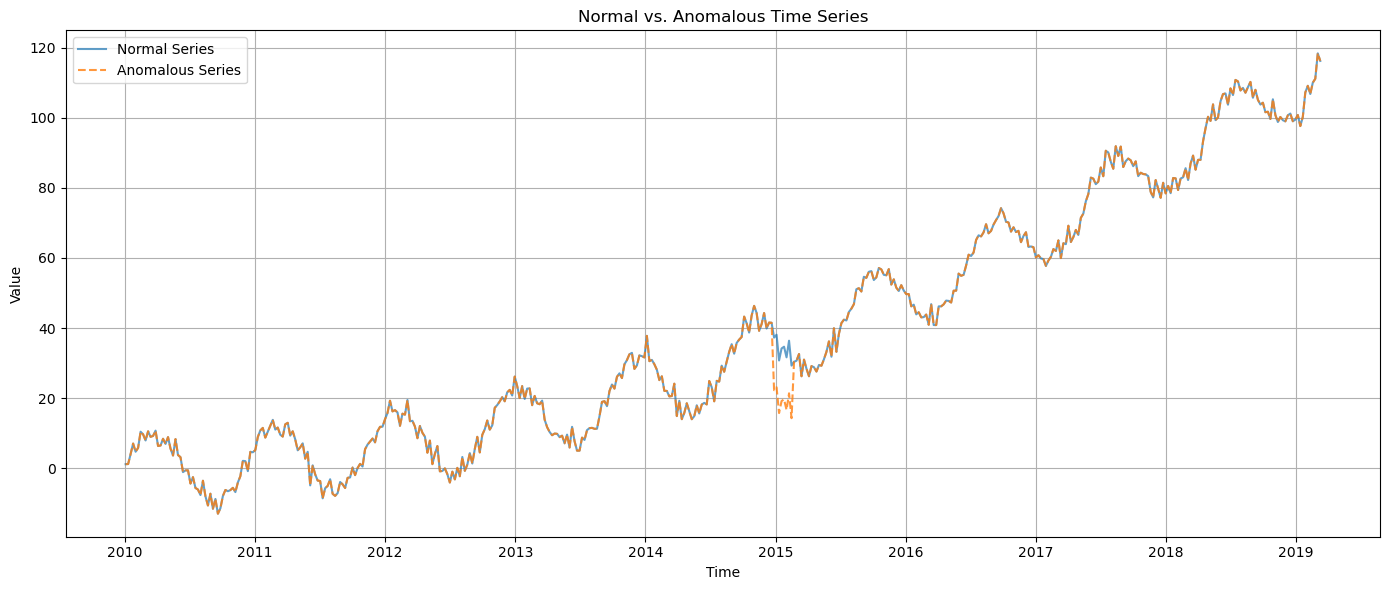

In [64]:
# Parameters
years = 10
months_per_year = 12
points_per_month = 4
total_points = years * months_per_year * points_per_month

# Time vector
t = np.arange(total_points)
time_index = pd.date_range(start='2010-01-01', periods=total_points, freq='W')

# Non-linear trend: quadratic + slight exponential
trend = 0.0005 * t**2 + 2 * np.exp(t / total_points) * 0.1

# Seasonality
seasonality = 10 * np.sin(2 * np.pi * t / (12 * points_per_month))

# Seasonality with extreme year
anomaly = np.zeros_like(t)

anomaly_start = 5 * 12 * points_per_month  # Start of year 6
anomaly_end = 6 * 12 * points_per_month    # End of year 6

# Apply anomaly for 3 months, e.g., June–August (middle of year 6)
june_idx = anomaly_start + 5 * points_per_month  # June
august_idx = anomaly_start + 7 * points_per_month  # August

# Create an anomaly during this period
anomaly[june_idx:august_idx] = -15 

# White noise
np.random.seed(42)
noise = np.random.normal(scale=2.0, size=total_points)

# Final time series
series_normal = trend + seasonality + noise
series_extreme = trend + anomaly + seasonality + noise

# Put in DataFrame
df = pd.DataFrame({'date': time_index, 'normal': series_normal, 'anomalous': series_extreme})

df.set_index('date', inplace=True)

# Plot both series
plt.figure(figsize=(14, 6))
plt.plot(time_index, series_normal, label='Normal Series', alpha=0.7)
plt.plot(time_index, series_extreme, label='Anomalous Series', alpha=0.8, linestyle='--')

plt.title('Normal vs. Anomalous Time Series')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 2. Load Mumbai (Aw) precipitation data

**Source:** https://data.opencity.in/dataset/mumbai-rainfall-data

<Axes: xlabel='Date'>

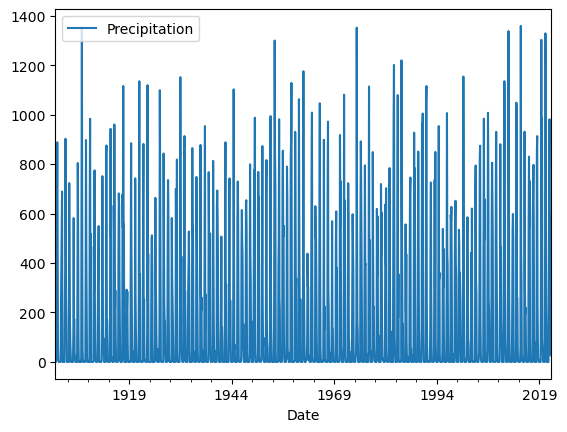

In [65]:
# Import Mumbai precipitation data
mumbai_precipitation = pd.read_csv('data/mumbai-monthly-rains.csv')

mumbai_precipitation.drop(columns='Total', inplace=True)

# Define mapping to fix month names
month_mapping = {
    'Jan': 'Jan', 'Feb': 'Feb', 'Mar': 'Mar',
    'April': 'Apr', 'May': 'May', 'June': 'Jun', 'July': 'Jul',
    'Aug': 'Aug', 'Sept': 'Sep', 'Oct': 'Oct', 'Nov': 'Nov', 'Dec': 'Dec'
}

# Rename columns using the mapping
mumbai_precipitation.rename(columns=month_mapping, inplace=True)

# Melt the DataFrame
mumbai_precipitation_melted = mumbai_precipitation.melt(
    id_vars='Year',
    var_name='Month',
    value_name='Precipitation'
)

# Convert to datetime
mumbai_precipitation_melted['Date'] = pd.to_datetime(
    mumbai_precipitation_melted['Year'].astype(str) + '-' + mumbai_precipitation_melted['Month'],
    format='%Y-%b'
)

# Final cleanup
mumbai_precipitation_melted.drop(columns=['Year', 'Month'], inplace=True)
mumbai_precipitation_melted.set_index('Date', inplace=True)

mumbai_precipitation_melted.sort_index(inplace=True)

mumbai_precipitation_melted.plot()


## 3. Seasonal decomposition of the data

In [66]:
# Synthetic normal data
dec_normal = STL(series_normal, period = 48).fit()

# Synthetic data with anomaly
dec_extreme = STL(series_extreme, period = 48).fit()

# Mumbai precipitation
dec_monsoon = STL(mumbai_precipitation_melted.loc['1990':'2000'], period=12).fit() # also only 10 years

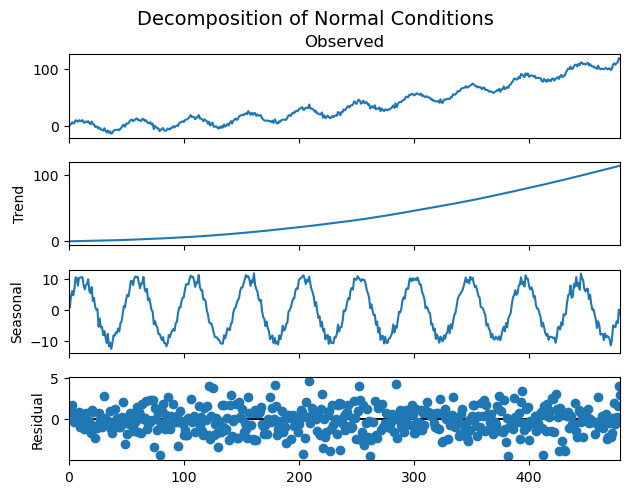

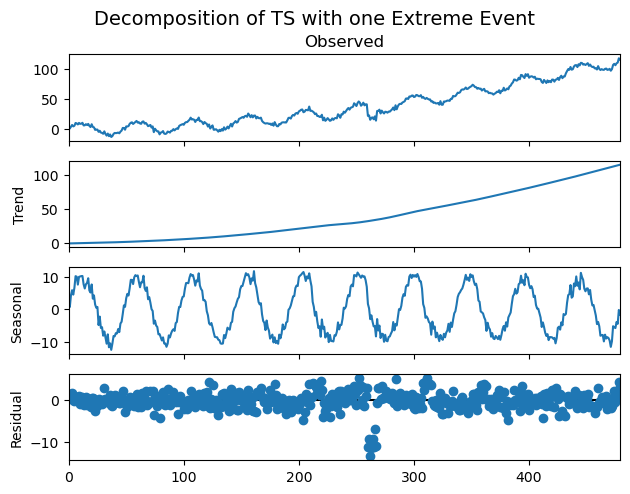

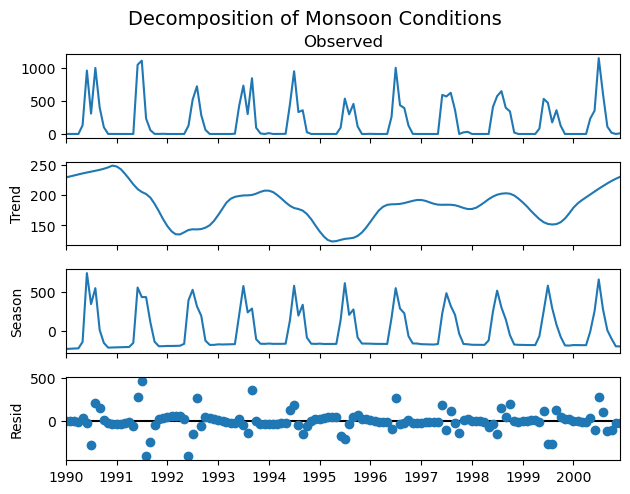

In [67]:
# Plot decompositions
fig1 = dec_normal.plot()
fig1.suptitle("Decomposition of Normal Conditions", fontsize=14, y=1.02)

fig2 = dec_extreme.plot()
fig2.suptitle("Decomposition of TS with one Extreme Event", fontsize=14, y=1.02)

fig3 = dec_monsoon.plot()
fig3.suptitle("Decomposition of Monsoon Conditions", fontsize=14, y=1.02)

plt.show()

## 5. Test decomposition performance
- performance of decomposition on synthetic data can be assessed by quantifying the differences between the components from the normal and the anomalous TS
- residuals should be white noise, i.e. no significant autocorrelation spikes

### 5.1 Compare deviations caused by extreme event


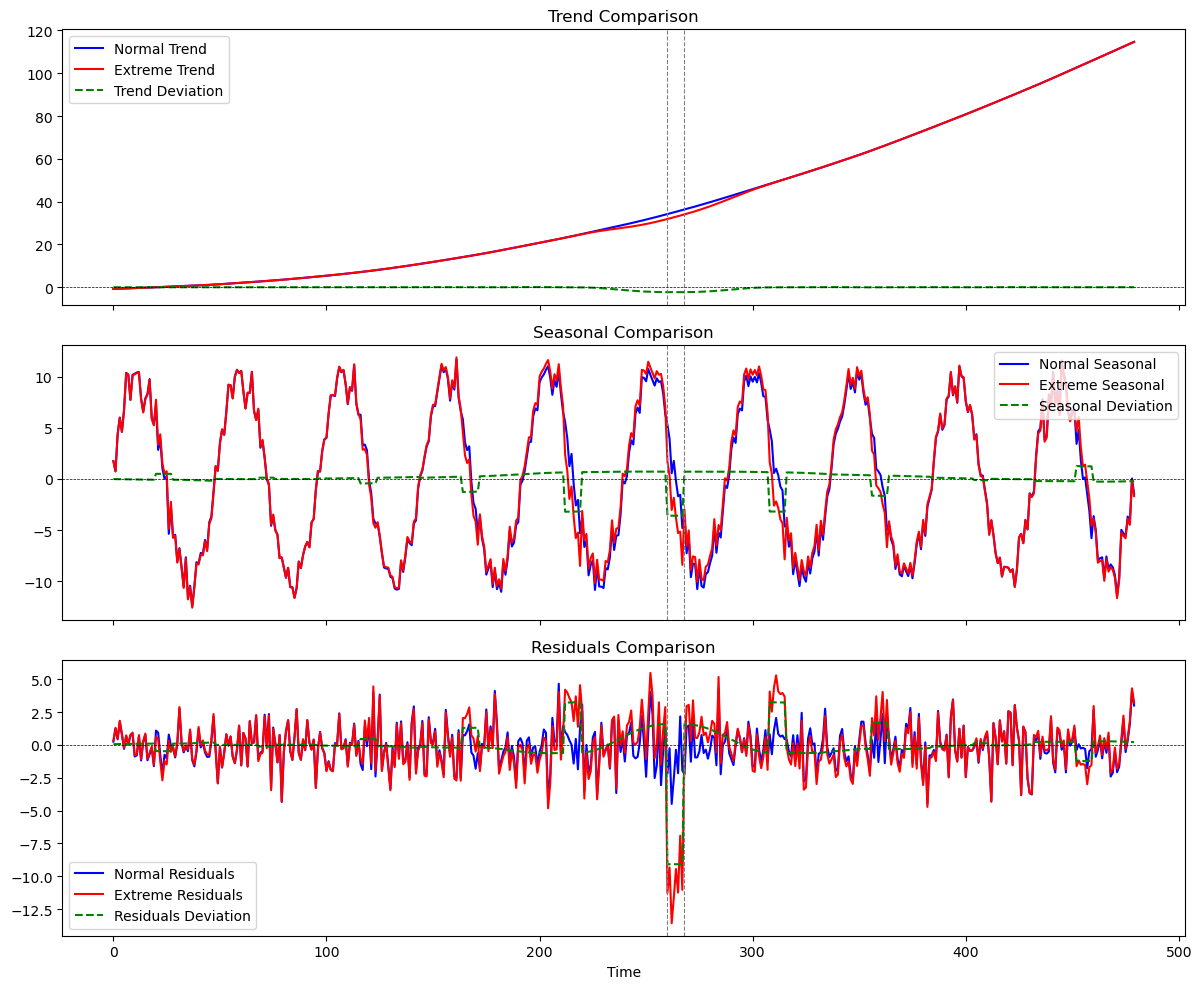

In [68]:
# Compute deviations
deviation_trend =  dec_extreme.trend - dec_normal.trend
deviation_seasonal =  dec_extreme.seasonal - dec_normal.seasonal
deviation_residuals = dec_extreme.resid - dec_normal.resid

# Create figure and axes
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot Trend
axes[0].plot(dec_normal.trend, label='Normal Trend', color='blue')
axes[0].plot(dec_extreme.trend, label='Extreme Trend', color='red')
axes[0].plot(deviation_trend, label='Trend Deviation', color='green', linestyle='--')
axes[0].set_title('Trend Comparison')
axes[0].legend()

# Plot Seasonal
axes[1].plot(dec_normal.seasonal, label='Normal Seasonal', color='blue')
axes[1].plot(dec_extreme.seasonal, label='Extreme Seasonal', color='red')
axes[1].plot(deviation_seasonal, label='Seasonal Deviation', color='green', linestyle='--')
axes[1].set_title('Seasonal Comparison')
axes[1].legend()

# Plot Residuals
axes[2].plot(dec_normal.resid, label='Normal Residuals', color='blue')
axes[2].plot(dec_extreme.resid, label='Extreme Residuals', color='red')
axes[2].plot(deviation_residuals, label='Residuals Deviation', color='green', linestyle='--')
axes[2].set_title('Residuals Comparison')
axes[2].legend()

plt.xlabel('Time')
for ax in axes:
    ax.axvline(june_idx, color='gray', linestyle='--', linewidth=0.8)
    ax.axvline(august_idx, color='gray', linestyle='--', linewidth=0.8)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

### 5.2 Autocorrelation Function (ACF) of Residuals

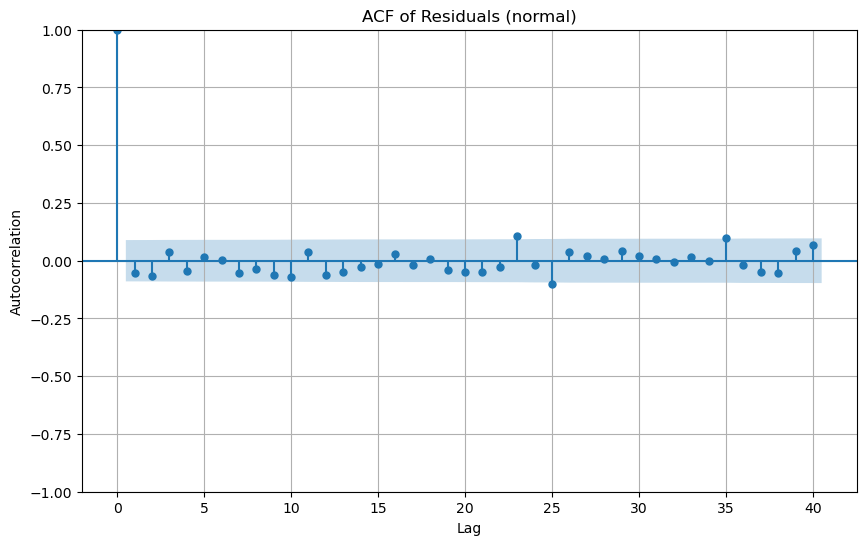

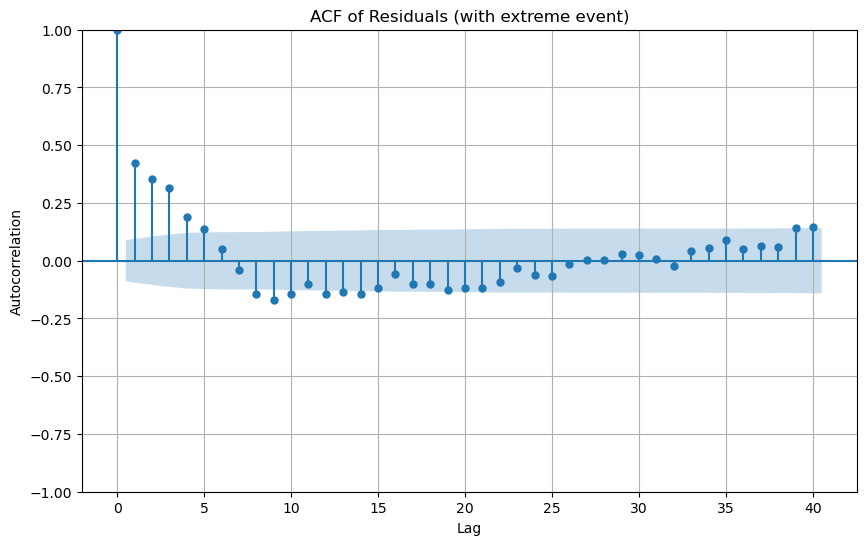

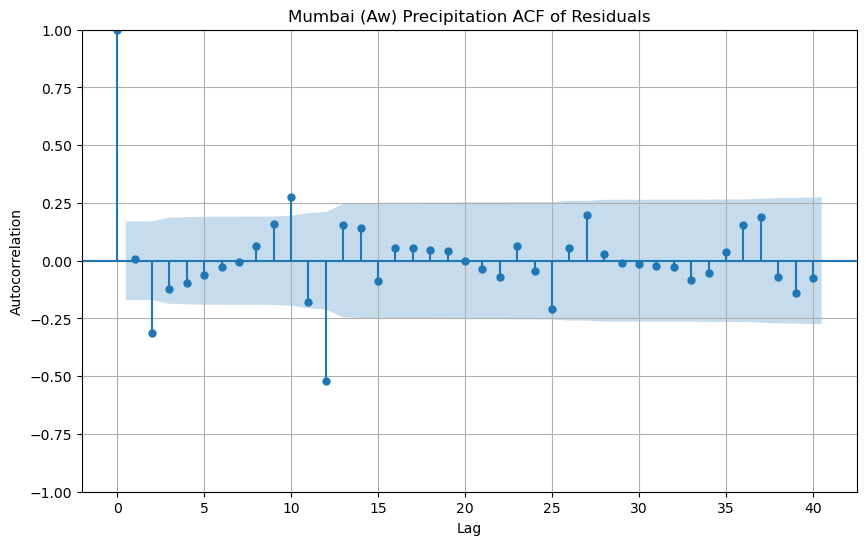

In [69]:
# Create the plot using plot_acf
fig, ax = plt.subplots(figsize=(10, 6))
plot_acf(dec_normal.resid, ax=ax, lags=40, alpha=0.05)
plt.title('ACF of Residuals (normal)')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
plot_acf(dec_extreme.resid, ax=ax, lags=40, alpha=0.05)
plt.title('ACF of Residuals (with extreme event)')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
plot_acf(dec_monsoon.resid, ax=ax, lags=40, alpha=0.05)
plt.title('Mumbai (Aw) Precipitation ACF of Residuals')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

**Synthetic without extreme event:** Almost all time lags are insignificant. lag 23 and 35 have slightly significant positive correlations and lag 25 slightly significant negative correlation.

**Synthetic with extreme event:** The plot shows seveal significant spikes which decrease first with increasing time lag, converge to 0 and then again increase but in the negative direction. This waveform may be due to the sine used to generate the synthetic data.

**Mumbai (Aw):** The plot shows several significant spikes. There are noticeable negative correlations around 3 and 12 (negative) and 10 (positive).

Interpretation of Residual Autocorrelation:

If the residuals of a time series model (like those from a decomposition) are truly white noise, their autocorrelation function should ideally show no significant correlations at any lag other than lag 0. The presence of significant autocorrelation in the residuals, as seen in this plot, suggests that there is still unexplained structure or dependence in the time series data that the decomposition model did not capture. Specifically, the significant spikes indicate that the residuals are not random and that past residual values can predict future residual values. This implies that the model might not be adequately capturing all the temporal dependencies in the original time series.

Possible Implications:

The underlying time series might have remaining seasonality or trend components that were not fully removed by the decomposition. There might be autocorrelation in the original series that the decomposition model didn't account for, indicating a need for a more sophisticated model (e.g., ARIMA or similar models) if the goal is to model and forecast the series. The presence of significant spikes at specific lags could suggest yearly or half-yearly seasonality that was not captured or fully removed by the decomposition if the data is, for example, monthly or bi-weekly.

### 5.3 Histogram of Residuals

Normal TS


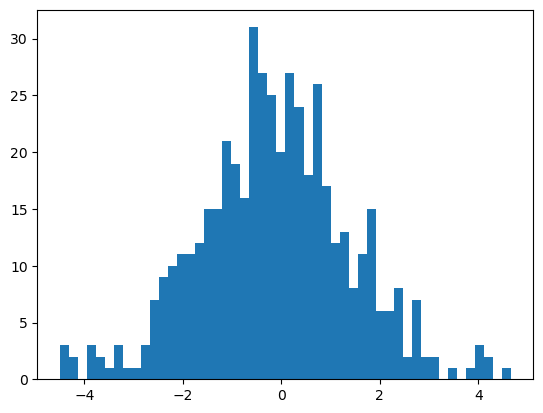

TS with extreme event


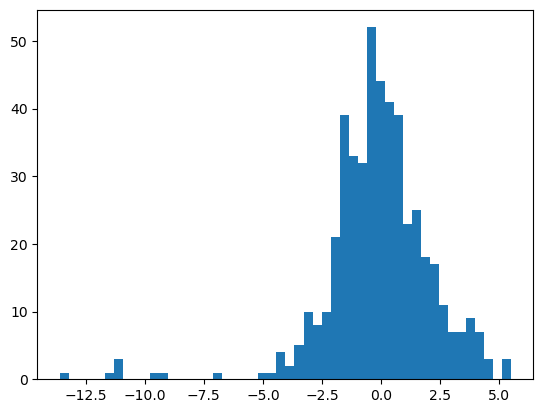

TS with monsoon


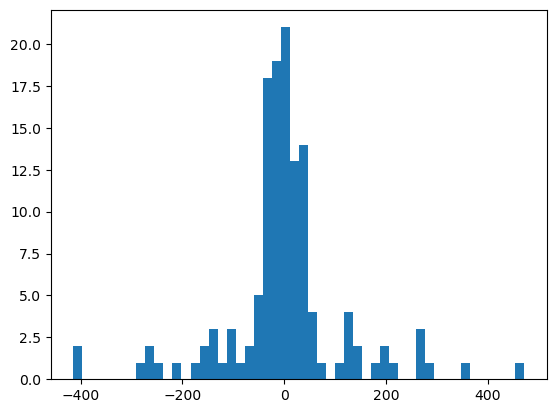

In [70]:
print('Normal TS')
plt.hist(dec_normal.resid, bins=50, label='normal')
plt.show()
print('TS with extreme event')
plt.hist(dec_extreme.resid, bins=50, label='with extreme event')
plt.show()
print('TS with monsoon')
plt.hist(dec_monsoon.resid, bins=50, label='Mumbai (Aw) Precipitation')
plt.show()

The histogram with extreme event shows a skewed distributionion, indicating that the residuals are not normally distributed. But I think this is okay since the residuals should be the component that has information about the extreme event.

## 6. Decomposition optimization
- adapt synthesized data to real data
    - frequency, amplitude, periodicity
    - 
- parameterize the error
- optimize by reducing this error

It seems like I could just use the robust parameter in STL() which makes the estimation more robust to outliers in the residuals.

### 5.1 Determine usual frequency, amplitude, periodicity of the data

In [71]:
# Load Earth System Data Cube store
store = new_data_store("s3", root="deep-esdl-public", storage_options=dict(anon=True))
ds_esdc = store.open_data('esdc-8d-0.25deg-1x720x1440-3.0.1.zarr')

kndvi = ds_esdc['kndvi'].sel(time=slice('2001-01-01', '2010-12-31'))

# Build land mask: True where kndvi has valid values across any time
land_mask = kndvi.notnull().any(dim='time').compute()

# Stack lat/lon into points, reset index to access lat/lon directly
stacked = land_mask.stack(points=('lat', 'lon')).reset_index('points')
land_points = stacked.where(stacked, drop=True)

# Extract actual lat/lon coordinate values
lats = land_points['lat'].values
lons = land_points['lon'].values
land_coords = list(zip(lats, lons))

# Separate into hemispheres
north_coords = [pt for pt in land_coords if pt[0] > 0]
south_coords = [pt for pt in land_coords if pt[0] < 0]

# Sample 68 random points from Northern Hemisphere, 32 from Southern
np.random.seed(42)
sample_north = np.random.choice(len(north_coords), 34, replace=False)
sample_south = np.random.choice(len(south_coords), 16, replace=False)

# Collect time series
all_series = []
for idx in sample_north:
    lat, lon = north_coords[idx]
    ts = kndvi.sel(lat=lat, lon=lon, method='nearest').values
    all_series.append(ts)

for idx in sample_south:
    lat, lon = south_coords[idx]
    ts = -kndvi.sel(lat=lat, lon=lon, method='nearest').values  # reverse sign
    all_series.append(ts)

# Convert to DataFrame
df = pd.DataFrame(all_series).T  # each column is a location
df.index = kndvi['time'].values

print(df.head())
print(f"Shape: {df.shape} (time steps × 100 locations)")


KeyboardInterrupt: 

In [61]:
print(kndvi.shape)
print(kndvi.time.values[:5])
print(kndvi.isnull().all())  # True if all values are NaN


(0, 720, 1440)
[]
<xarray.DataArray 'kndvi' ()> Size: 1B
dask.array<all-aggregate, shape=(), dtype=bool, chunksize=(), chunktype=numpy.ndarray>


In [53]:
print(kndvi.lat.values[:5])
print(kndvi.lon.values[:5])


[-89.875 -89.625 -89.375 -89.125 -88.875]
[-179.875 -179.625 -179.375 -179.125 -178.875]
